# Task 3: Neural Surrogate, Architecture 3 of 4 (Multi-Head MLP, plain 3-head)

Third of four feed-forward architectures compared in Task 3. The Multi-Head
MLP groups the 15 modeled outputs by physical role into separate prediction
heads on top of a shared trunk. This is the structural difference from the
single-head Deep MLP and Residual MLP.

Architecture:
1. Shared trunk: `n_trunk_layers` in {1, 2} blocks of `Linear, GELU, LayerNorm, Dropout(p)`, width `h_trunk = 64`.
2. 3 heads (each `Linear(h_trunk, h_head), GELU, Dropout(p), Linear(h_head, out)`), with `h_head` in {h_trunk//2, h_trunk} = {32, 64}:
   - `head_scalar`: Q1_MW, Q2_MW, T_reactor_out, X_CO, n3_total, MeOH_recovery (6)
   - `head_vapor`: y_CO_3, y_H2_3, y_MeOH_3, y_H2O_3 (4)
   - `head_liquid`: n4_total, x_CO_4, x_H2_4, x_MeOH_4, x_H2O_4 (5)
3. Loss: plain MSE in standardized space, same as Deep MLP and Residual MLP.

The no-liquid regime is handled at inference time by a local
`assemble_with_zero_injection` helper (defined in section 3): wherever the predicted
`n4_total` falls below a small threshold, the four `x_*_4` outputs are forced
to 0 (and `MeOH_purity_stream4` follows). `nn_utils.assemble_full_prediction`
is unchanged, so the zero-injection is local to this notebook and the Deep MLP and
Residual MLP test metrics are not affected.

Sweep: core training hyperparameters are locked to the Residual MLP iter-2
winner (`lr=1e-3`, `wd=5e-4`); trunk width fixed at `h_trunk=64`, and the
sweep runs over `dropout`, `n_trunk_layers`, and `h_head_mode` = 2 by 2 by 2 = 8 configs
(`dropout` in {0.20, 0.30}). Dropout is swept here to check whether the lighter
0.20 used by the Residual MLP also works for the multi-head split, or whether the
heavier 0.30 regularises the extra head parameters better.

Conventions (same as `EDA&ElasticNet.ipynb`, `XGBoost.ipynb`, `NN_DeepMLP.ipynb`, `NN_ResidualMLP.ipynb`):
- 9 inputs, 15 modeled outputs; 4 deterministic outputs (`T3`, `P3`, `P4`, `MeOH_purity_stream4`) recovered by direct assignment.
- `x_H2_4` trained in log-space; the other 14 outputs are standardized only.
- 80/20 train/val split stratified on `n4_total == 0`, `random_state=42`.
- Test set (`dataset/test.csv`) is untouched until the final evaluation cells.

Targets to beat:
- Aggregate test R² at least 0.987 (XGBoost), and ideally 0.99213 (Residual MLP).
- `x_MeOH_4` test R² at least 0.95 (Residual MLP 0.9588, Deep MLP and XGBoost 0.962).
- No-liquid slice R² at least 0.389 (XGBoost); with zero-injection this should be easy.

Note: a prior cascade attempt was reverted. An earlier version of this notebook
used a cascaded gate design (`head_n4` gating `head_liquid` through a soft
sigmoid and a learnable `zero_proxy` baseline). It did not work: aggregate test R²
dropped to 0.96067 because (a) only 10 no-liquid train rows could not teach
the gate threshold, and (b) the `zero_proxy` value of -24 for the
log-transformed `x_H2_4` added a constant bias on every forward pass. The current
plain 3-head design replaces it. See the retrospective in section 15 for the full
diagnosis.

## 0. Install PyTorch (run once)

In [1]:
import subprocess, sys
for pkg in ["torch"]:
    try:
        __import__(pkg)
        print(f"{pkg} already installed")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        print("\n*** Restart the kernel before running the remaining cells. ***")

torch already installed


## 1. Imports and reproducibility

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

import nn_utils as nu
from nn_utils import (
    INPUT_COLS, OUTPUT_COLS, MODEL_OUTPUT_COLS, RANDOM_STATE,
    load_data, build_scaled_split, make_dataloaders,
    TrainConfig, train_model, predict_raw,
    regression_metrics_by_output, regime_diagnostics,
    assemble_full_prediction, parity_grid, save_checkpoint,
)

nu.seed_everything(RANDOM_STATE)
device = "cpu" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device: {device}")

torch 2.5.1+cu121 | device: cpu


## 2. Load data

Same loading convention as `XGBoost.ipynb`, `NN_DeepMLP.ipynb`, and
`NN_ResidualMLP.ipynb`: 9 inputs, 19 raw outputs (we model 15).

In [3]:
data = load_data("dataset")
print(f"Train : {len(data.X_train):>5} rows | {len(INPUT_COLS)} inputs | {len(OUTPUT_COLS)} outputs")
print(f"Test  : {len(data.X_test):>5} rows")
print(f"No-liquid rows — train: {data.no_liquid_train.sum()} | test: {data.no_liquid_test.sum()}")
print(f"\nModeled outputs ({len(MODEL_OUTPUT_COLS)}): {MODEL_OUTPUT_COLS}")

Train :  8000 rows | 9 inputs | 19 outputs
Test  :  2000 rows
No-liquid rows — train: 13 | test: 4

Modeled outputs (15): ['Q1_MW', 'Q2_MW', 'T_reactor_out', 'X_CO', 'n3_total', 'y_CO_3', 'y_H2_3', 'y_MeOH_3', 'y_H2O_3', 'n4_total', 'x_CO_4', 'x_H2_4', 'x_MeOH_4', 'x_H2O_4', 'MeOH_recovery']


## 3. Train/val split, scaling pipeline, and zero-injection helper

Carve an 80/20 train/val split out of `train.csv`, stratified on the no-liquid
indicator. Fit `StandardScaler` on the training portion only. Targets pass
through `log` on `x_H2_4` first (with the `LOG_FLOOR=1e-10` clip from
`nn_utils.TargetTransformer`), then `StandardScaler` on the resulting 15-column
matrix.

This cell also defines `assemble_with_zero_injection`, a local variant of
`nn_utils.assemble_full_prediction` that zeroes out the four
`x_*_4` mole fractions wherever the model's predicted `n4_total` falls
below a small threshold. This is the inference-time fix for the no-liquid
regime. `nn_utils.assemble_full_prediction` itself is unchanged, so the
Deep MLP and Residual MLP test metrics in section 12 (loaded from their
checkpoints) are not affected.

In [4]:
scaled = build_scaled_split(data, val_size=0.2, seed=RANDOM_STATE)

print(f"Train fit : {len(scaled.train_idx):>5} rows | no-liquid: {scaled.no_liquid_train_fit.sum()}")
print(f"Val       : {len(scaled.val_idx):>5} rows | no-liquid: {scaled.no_liquid_val.sum()}")


def assemble_with_zero_injection(pred_modeled, X_ref, n4_threshold=0.05):
    """Like nn_utils.assemble_full_prediction, but where the predicted
    n4_total <= n4_threshold, force n4_total = 0, x_CO_4, x_H2_4, x_MeOH_4,
    x_H2O_4 = 0, and MeOH_purity_stream4 = 0 (the latter is derived from
    x_MeOH_4). All five output columns are made internally consistent with
    the dataset convention for no-liquid rows.

    Local to this notebook; nn_utils.assemble_full_prediction is unchanged.
    """
    df = assemble_full_prediction(pred_modeled, X_ref).copy()
    no_liquid_pred = df["n4_total"].values <= n4_threshold   # mask BEFORE modifying n4_total
    df.loc[no_liquid_pred, "n4_total"] = 0.0
    for col in ["x_CO_4", "x_H2_4", "x_MeOH_4", "x_H2O_4"]:
        df.loc[no_liquid_pred, col] = 0.0
    df.loc[no_liquid_pred, "MeOH_purity_stream4"] = 0.0
    return df


# Default threshold used throughout the notebook.
N4_THRESHOLD = 0.05
print(f"\nZero-injection threshold N4_THRESHOLD = {N4_THRESHOLD}")
print(f"  (training-set liquid rows have n4_total > 1; no-liquid rows have n4_total = 0)")

Train fit :  6400 rows | no-liquid: 10
Val       :  1600 rows | no-liquid: 3

Zero-injection threshold N4_THRESHOLD = 0.05
  (training-set liquid rows have n4_total > 1; no-liquid rows have n4_total = 0)


## 4. Multi-Head MLP architecture (plain 3-head, no cascade)

`MultiHeadMLP` is a 3-head model on top of a shared trunk. Each head is a
single-hidden-layer MLP. The three heads' outputs are scattered into the
15-column order (matching `MODEL_OUTPUT_COLS`) so the rest of the
pipeline (`train_model`, `predict_raw`, `assemble_full_prediction`,
`regression_metrics_by_output`) stays unchanged.

```
trunk(x)              ->  h                          (B, h_trunk)
head_scalar(h)        ->  scalar_pred                (B, 6)
head_vapor(h)         ->  vapor_pred                 (B, 4)
head_liquid(h)        ->  liquid_pred                (B, 5)   # includes n4_total
out (15-vector)        :  scatter the 3 head outputs into MODEL_OUTPUT_COLS order
```

Head grouping rationale:
- `head_scalar` groups outputs that do not share strong physical structure
  with each other (heat duties, conversion, KPI). The KPI `MeOH_recovery` is
  included here rather than getting its own 1-output head, which would waste
  parameters.
- `head_vapor` predicts the four stream-3 mole fractions, which share an
  implicit sum-to-one constraint.
- `head_liquid` predicts `n4_total` and the four stream-4 mole fractions
  together. `n4_total` is the physical signal of whether liquid exists, so
  keeping it with the mole fractions gives this head the full picture in
  one place. Inference-time zero-injection (defined in section 3) uses the predicted
  `n4_total` to gate the four `x_*_4` outputs.

In [5]:
# Output groupings (indices in MODEL_OUTPUT_COLS):
#   [0] Q1_MW [1] Q2_MW [2] T_reactor_out [3] X_CO [4] n3_total
#   [5] y_CO_3 [6] y_H2_3 [7] y_MeOH_3 [8] y_H2O_3
#   [9] n4_total
#   [10] x_CO_4 [11] x_H2_4 (log) [12] x_MeOH_4 [13] x_H2O_4
#   [14] MeOH_recovery
SCALAR_IDX = [0, 1, 2, 3, 4, 14]    # Q1_MW, Q2_MW, T_reactor_out, X_CO, n3_total, MeOH_recovery
VAPOR_IDX  = [5, 6, 7, 8]           # y_CO_3, y_H2_3, y_MeOH_3, y_H2O_3
LIQUID_IDX = [9, 10, 11, 12, 13]    # n4_total, x_CO_4, x_H2_4, x_MeOH_4, x_H2O_4


class HeadMLP(nn.Module):
    """One head: Linear(in -> h_head) -> GELU -> Dropout -> Linear(h_head -> out)."""

    def __init__(self, in_dim: int, h_head: int, out_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h_head),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h_head, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class MultiHeadMLP(nn.Module):
    """
    Plain 3-head MLP. Shared trunk + per-group heads. No gating, no
    cascade, no learnable constants beyond standard nn.Linear weights.

      trunk(x)        -> h           (B, h_trunk)
      head_scalar(h)  -> (B, 6)      # Q1_MW, Q2_MW, T_reactor_out, X_CO, n3_total, MeOH_recovery
      head_vapor(h)   -> (B, 4)      # y_CO_3, y_H2_3, y_MeOH_3, y_H2O_3
      head_liquid(h)  -> (B, 5)      # n4_total, x_CO_4, x_H2_4, x_MeOH_4, x_H2O_4

    The three head outputs are scattered into a (B, 15) tensor in
    MODEL_OUTPUT_COLS order so the downstream `nn_utils` helpers
    (`predict_raw`, `assemble_full_prediction`, etc.) work unchanged.
    """

    SCALAR_IDX = SCALAR_IDX
    VAPOR_IDX  = VAPOR_IDX
    LIQUID_IDX = LIQUID_IDX
    OUT_DIM    = 15

    def __init__(
        self,
        in_dim: int = len(INPUT_COLS),
        h_trunk: int = 64,
        n_trunk_layers: int = 3,
        h_head: int = 32,
        dropout: float = 0.30,
    ):
        super().__init__()
        # --- Shared trunk: stack of (Linear -> GELU -> LayerNorm -> Dropout) ---
        trunk_layers = []
        prev = in_dim
        for _ in range(n_trunk_layers):
            trunk_layers.append(nn.Linear(prev, h_trunk))
            trunk_layers.append(nn.GELU())
            trunk_layers.append(nn.LayerNorm(h_trunk))
            trunk_layers.append(nn.Dropout(dropout))
            prev = h_trunk
        self.trunk = nn.Sequential(*trunk_layers)

        # --- 3 heads ---
        self.head_scalar = HeadMLP(h_trunk, h_head, len(self.SCALAR_IDX), dropout)
        self.head_vapor  = HeadMLP(h_trunk, h_head, len(self.VAPOR_IDX),  dropout)
        self.head_liquid = HeadMLP(h_trunk, h_head, len(self.LIQUID_IDX), dropout)

    def forward(self, x):
        h = self.trunk(x)
        scalar_pred = self.head_scalar(h)    # (B, 6)
        vapor_pred  = self.head_vapor(h)     # (B, 4)
        liquid_pred = self.head_liquid(h)    # (B, 5)

        out = torch.empty(x.size(0), self.OUT_DIM, device=x.device, dtype=x.dtype)
        out[:, self.SCALAR_IDX] = scalar_pred
        out[:, self.VAPOR_IDX]  = vapor_pred
        out[:, self.LIQUID_IDX] = liquid_pred
        return out


# Sanity check
_baseline = MultiHeadMLP(h_trunk=64, n_trunk_layers=3, h_head=32, dropout=0.30)
print(_baseline)
print(f"\nTrainable parameters (h_trunk=64, n_trunk_layers=3, h_head=32, dropout=0.30): "
      f"{sum(p.numel() for p in _baseline.parameters() if p.requires_grad):,}")

MultiHeadMLP(
  (trunk): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): GELU(approximate='none')
    (6): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): GELU(approximate='none')
    (10): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.3, inplace=False)
  )
  (head_scalar): HeadMLP(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=32, out_features=6, bias=True)
    )
  )
  (head_vapor): HeadMLP(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
    

## 5. Architecture and dropout sweep (8 configs, locked training HPs)

Core training hyperparameters are locked to the Residual MLP iter-2 winner;
the architectural axes plus dropout vary:

| Locked training HP | Value |
|---|---|
| `lr` | 1e-3 |
| `weight_decay` | 5e-4 |
| `batch_size` | 128 |
| `max_epochs` | 1000 |
| `ReduceLROnPlateau` | factor=0.5, patience=5, min_lr=1e-8 |
| `early_stopping_patience` | 60 |
| `grad_clip_norm` | 1.0 |
| `seed` | 42 |

| Swept axis | Grid |
|---|---|
| `dropout` | {0.20, 0.30} |
| `h_trunk` | {64} (fixed) |
| `n_trunk_layers` | {1, 2} |
| `h_head` | {`h_trunk // 2` = 32 ("half"), `h_trunk` = 64 ("full")} |

Total 2 by 2 by 2 = 8 configs (trunk width held at 64; dropout, depth and
head width vary). The parameter count ranges from about 7.5k to 18.5k (dropout does not
change the parameter count), which brackets the Residual MLP iter-2 winner of
17.9k and the Deep MLP winner of 14.6k. The winner is selected on
validation loss only; the test set is not touched in the sweep, the single
held-out evaluation runs on the winner in section 9. The 0.20 vs 0.30 marginal effect
is summarised in section 5b.

In [6]:
from itertools import product

# --- Locked training hyperparameters (Residual MLP iter-2 winner) ---
LR          = 1e-3
WD          = 5e-4
ES_PATIENCE = 60
MAX_EPOCHS  = 1000
BATCH_SIZE  = 128

# --- Architecture + dropout sweep grid ---
# Dropout is now a swept axis (0.20 vs 0.30) so the two are compared head-to-head;
# h_trunk stays fixed at 64. Grid = dropout x n_trunk_layers x head_mode = 2 x 2 x 2.
DROPOUT_GRID = [0.20, 0.30]
H_TRUNK      = 64
sweep_configs = []
for dropout, n_trunk_layers, head_mode in product(DROPOUT_GRID, [1, 2], ["half", "full"]):
    h_head = H_TRUNK // 2 if head_mode == "half" else H_TRUNK
    sweep_configs.append({
        "name":           f"ht{H_TRUNK}_nt{n_trunk_layers}_hh{h_head}_do{dropout:.2f}",
        "h_trunk":        H_TRUNK,
        "n_trunk_layers": n_trunk_layers,
        "h_head":         h_head,
        "head_mode":      head_mode,
        "dropout":        dropout,
    })

print(f"Total sweep configs: {len(sweep_configs)}")
for c in sweep_configs:
    print(f"  {c['name']}: n_trunk_layers={c['n_trunk_layers']}, h_head={c['h_head']}, dropout={c['dropout']}")

sweep_models    = {}
sweep_histories = {}
sweep_results   = []

for i, cfg in enumerate(sweep_configs, 1):
    print(f"\n=== [{i}/{len(sweep_configs)}] {cfg['name']} ===")
    nu.seed_everything(RANDOM_STATE)
    candidate = MultiHeadMLP(
        in_dim=len(INPUT_COLS),
        h_trunk=cfg["h_trunk"],
        n_trunk_layers=cfg["n_trunk_layers"],
        h_head=cfg["h_head"],
        dropout=cfg["dropout"],
    )
    n_params = sum(p.numel() for p in candidate.parameters() if p.requires_grad)
    train_loader, val_loader = make_dataloaders(scaled, batch_size=BATCH_SIZE, seed=RANDOM_STATE)
    cand_config = TrainConfig(
        max_epochs=MAX_EPOCHS,
        lr=LR,
        weight_decay=WD,
        lr_factor=0.5,
        lr_patience=5,
        lr_min=1e-8,
        early_stopping_patience=ES_PATIENCE,
        grad_clip_norm=1.0,
        device=device,
        log_every=200,
    )
    hist = train_model(candidate, train_loader, val_loader, config=cand_config)

    # Selection metric = best validation loss only; the test set is NOT touched
    # here. The single held-out evaluation happens on the winner in section 9.
    sweep_models[cfg["name"]]    = candidate
    sweep_histories[cfg["name"]] = hist
    sweep_results.append({
        "name":           cfg["name"],
        "h_trunk":        cfg["h_trunk"],
        "n_trunk_layers": cfg["n_trunk_layers"],
        "h_head":         cfg["h_head"],
        "head_mode":      cfg["head_mode"],
        "dropout":        cfg["dropout"],
        "params":         n_params,
        "best_val_loss":  hist.best_val_loss,
        "best_epoch":     hist.best_epoch,
        "epochs_run":     len(hist.val_loss),
    })
    print(f"  → best val {hist.best_val_loss:.5f} @ epoch {hist.best_epoch} | params={n_params:,}")

sweep_df = pd.DataFrame(sweep_results).sort_values("best_val_loss").reset_index(drop=True)
print("\nAll sweep configs (sorted by best val loss):")
print(sweep_df.round(5).to_string(index=False))

Total sweep configs: 8
  ht64_nt1_hh32_do0.20: n_trunk_layers=1, h_head=32, dropout=0.2
  ht64_nt1_hh64_do0.20: n_trunk_layers=1, h_head=64, dropout=0.2
  ht64_nt2_hh32_do0.20: n_trunk_layers=2, h_head=32, dropout=0.2
  ht64_nt2_hh64_do0.20: n_trunk_layers=2, h_head=64, dropout=0.2
  ht64_nt1_hh32_do0.30: n_trunk_layers=1, h_head=32, dropout=0.3
  ht64_nt1_hh64_do0.30: n_trunk_layers=1, h_head=64, dropout=0.3
  ht64_nt2_hh32_do0.30: n_trunk_layers=2, h_head=32, dropout=0.3
  ht64_nt2_hh64_do0.30: n_trunk_layers=2, h_head=64, dropout=0.3

=== [1/8] ht64_nt1_hh32_do0.20 ===
  epoch   1 | train 0.60903 | val 0.27029 | lr 1.00e-03 | best@1
  epoch   2 | train 0.27849 | val 0.16844 | lr 1.00e-03 | best@2
  epoch   3 | train 0.22597 | val 0.14318 | lr 1.00e-03 | best@3
  epoch   4 | train 0.20244 | val 0.12816 | lr 1.00e-03 | best@4
  epoch   5 | train 0.18881 | val 0.12093 | lr 1.00e-03 | best@5
  epoch   6 | train 0.18024 | val 0.11598 | lr 1.00e-03 | best@6
  epoch   7 | train 0.17225 | v

## 5b. Marginal effect of each architectural axis

For each sweep axis, average the best val loss across all other axes.

In [7]:
for axis in ["dropout", "n_trunk_layers", "h_head", "head_mode"]:
    marg = sweep_df.groupby(axis)["best_val_loss"].agg(["mean", "min", "count"]).round(5)
    print(f"\n--- by {axis} ---")
    print(marg.to_string())


--- by dropout ---
            mean      min  count
dropout                         
0.2      0.05135  0.04797      4
0.3      0.05881  0.04909      4

--- by n_trunk_layers ---
                   mean      min  count
n_trunk_layers                         
1               0.05534  0.04797      4
2               0.05482  0.05179      4

--- by h_head ---
           mean      min  count
h_head                         
32      0.05903  0.04797      4
64      0.05113  0.04909      4

--- by head_mode ---
              mean      min  count
head_mode                         
full       0.05113  0.04909      4
half       0.05903  0.04797      4


## 6. Sweep diagnostics: loss curves of the top 6 configs

8 lines get crowded; show the best 6 (by validation loss) to capture the
winning regime.

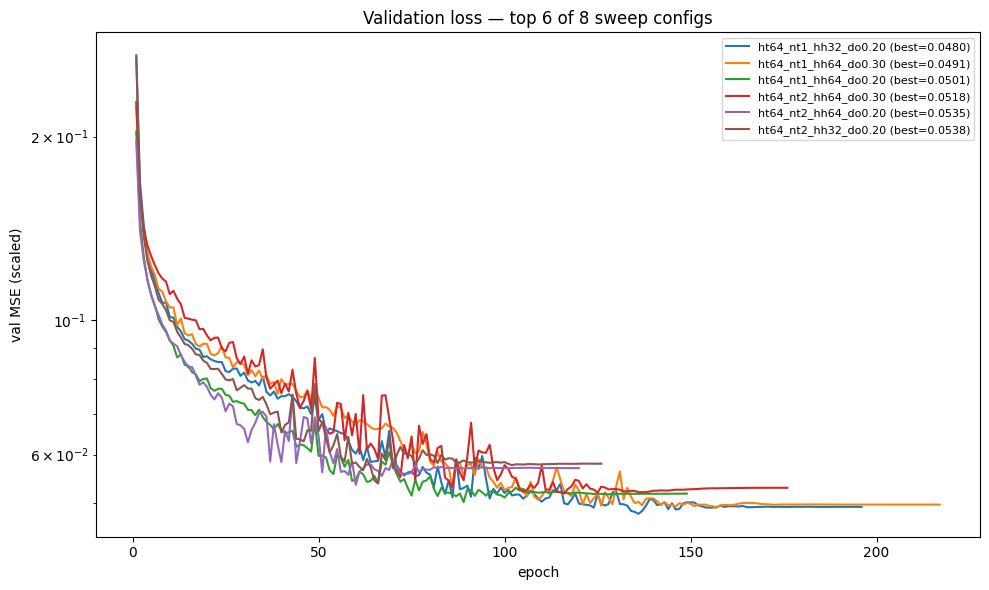

In [8]:
top_configs = sweep_df.head(6)["name"].tolist()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for name in top_configs:
    hist = sweep_histories[name]
    epochs = np.arange(1, len(hist.val_loss) + 1)
    ax.plot(epochs, hist.val_loss, label=f"{name} (best={hist.best_val_loss:.4f})")
ax.set_xlabel("epoch"); ax.set_ylabel("val MSE (scaled)")
ax.set_yscale("log"); ax.set_title("Validation loss — top 6 of 8 sweep configs")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## 7. Select winner and adopt as the final Multi-Head MLP

The lowest val-loss configuration is taken as the final model. The rest of the
notebook (test evaluation, parity plots, checkpoint) treats it as the
final Multi-Head MLP.

In [9]:
winner_name = sweep_df.iloc[0]["name"]
winner_cfg  = next(c for c in sweep_configs if c["name"] == winner_name)
model       = sweep_models[winner_name]
history     = sweep_histories[winner_name]

print(f"Winner: {winner_name}")
print(f"  architecture     : h_trunk={winner_cfg['h_trunk']}, "
      f"n_trunk_layers={winner_cfg['n_trunk_layers']}, h_head={winner_cfg['h_head']} "
      f"({winner_cfg['head_mode']}), dropout={winner_cfg['dropout']}")
print(f"  locked training  : lr={LR:.0e}, wd={WD:.0e}, ES patience={ES_PATIENCE}")
print(f"  best val loss    : {history.best_val_loss:.5f} at epoch {history.best_epoch}")
print(f"  trained epochs   : {len(history.val_loss)}")
print(f"  parameters       : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Winner: ht64_nt1_hh32_do0.20
  architecture     : h_trunk=64, n_trunk_layers=1, h_head=32 (half), dropout=0.2
  locked training  : lr=1e-03, wd=5e-04, ES patience=60
  best val loss    : 0.04797 at epoch 136
  trained epochs   : 196
  parameters       : 7,503


## 8. Final training curves (winner only)

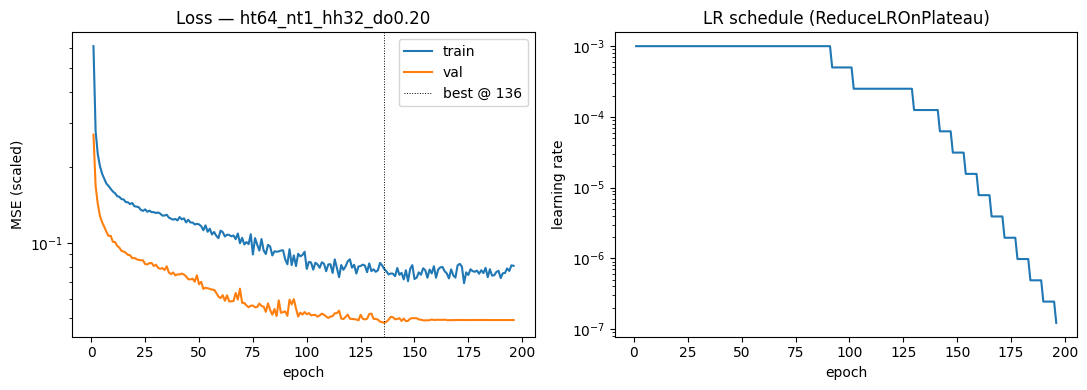

In [10]:
fig, (ax_loss, ax_lr) = plt.subplots(1, 2, figsize=(11, 4))
epochs = np.arange(1, len(history.train_loss) + 1)
ax_loss.plot(epochs, history.train_loss, label="train")
ax_loss.plot(epochs, history.val_loss, label="val")
ax_loss.axvline(history.best_epoch, color="k", lw=0.7, ls=":", label=f"best @ {history.best_epoch}")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("MSE (scaled)")
ax_loss.set_yscale("log"); ax_loss.set_title(f"Loss — {winner_name}"); ax_loss.legend()

ax_lr.plot(epochs, history.lr)
ax_lr.set_xlabel("epoch"); ax_lr.set_ylabel("learning rate")
ax_lr.set_yscale("log"); ax_lr.set_title("LR schedule (ReduceLROnPlateau)")
plt.tight_layout(); plt.show()

## 9. Test-set evaluation (with zero-injection)

Predict the held-out `test.csv`, invert the target transform, then use
`assemble_with_zero_injection` (defined in section 3) to recover the 4
deterministic outputs and zero out the four `x_*_4` mole fractions wherever
the predicted `n4_total` falls below `N4_THRESHOLD`.

The metric tables here are directly comparable with the EN, XGBoost, Deep
MLP, and Residual MLP reports for the rows where zero-injection did not fire;
the no-liquid slice (section 11) is where the difference matters most.

In [11]:
test_pred_modeled = predict_raw(model, scaled.X_test_s, scaled.Y_transformer, device=device)
test_pred_full    = assemble_with_zero_injection(test_pred_modeled, data.X_test, n4_threshold=N4_THRESHOLD)

n_injected = int((test_pred_full["n4_total"].values <= N4_THRESHOLD).sum())
print(f"Zero-injection fired on {n_injected} / {len(test_pred_full)} test rows "
      f"(N4_THRESHOLD = {N4_THRESHOLD}).")

mhmlp_test_per_output = regression_metrics_by_output(
    data.y_test, test_pred_full, OUTPUT_COLS
).sort_values("RMSE", ascending=False)

print("\nMulti-Head MLP — test per-output metrics (sorted by RMSE, worst first):")
mhmlp_test_per_output.round(5)

Zero-injection fired on 4 / 2000 test rows (N4_THRESHOLD = 0.05).

Multi-Head MLP — test per-output metrics (sorted by RMSE, worst first):


,output,RMSE,MAE,R2
6,n3_total,21.86091,16.88030,0.99091
12,n4_total,2.06130,1.55858,0.99168
2,T_reactor_out,0.89861,0.66361,0.98872
0,Q1_MW,0.04852,0.03721,0.98985
17,MeOH_recovery,0.01823,0.01156,0.98977
18,MeOH_purity_stream4,0.01537,0.00848,0.99010
15,x_MeOH_4,0.01537,0.00848,0.99010
16,x_H2O_4,0.01068,0.00786,0.99510
8,y_H2_3,0.00440,0.00326,0.99521
7,y_CO_3,0.00436,0.00323,0.99528


## 10. Aggregate test metrics

In [12]:
mhmlp_m = regression_metrics_by_output(data.y_test, test_pred_full, OUTPUT_COLS)
print(
    f"Multi-Head MLP test — "
    f"RMSE: {mhmlp_m['RMSE'].mean():.5f} | "
    f"MAE: {mhmlp_m['MAE'].mean():.5f} | "
    f"R²: {mhmlp_m['R2'].mean(skipna=True):.5f}"
)

Multi-Head MLP test — RMSE: 1.31279 | MAE: 1.00979 | R²: 0.98743


## 11. Regime diagnostics and n4-prediction diagnostic

The first table is the standard `regime_diagnostics` split (all / liquid /
no-liquid) computed on the zero-injected predictions.

The second part is the n4-prediction diagnostic: a scatter of predicted
vs true `n4_total` on test rows, with the `N4_THRESHOLD` line drawn. This
shows how cleanly the `head_liquid` n4 output separates the two
regimes and confirms that the threshold picks up the 4 no-liquid
test rows.

Regime diagnostics (all / liquid / no-liquid):
         group  rows  mean_RMSE  mean_MAE  mean_R2
      all_rows  2000    1.31279   1.00979  0.98743
   liquid_rows  1996    1.31013   1.00862  0.98707
no_liquid_rows     4    2.17108   1.59498  0.19108

n4 prediction summary:
  Liquid rows    (1996): pred mean=59.523, min=2.802, max=120.654
  No-liquid rows (   4): pred mean=0.0000, min=0.0000, max=0.0000

Zero-injection breakdown (N4_THRESHOLD = 0.05):
  fired on 4 test rows total (4 true no-liquid, 0 false-positive)


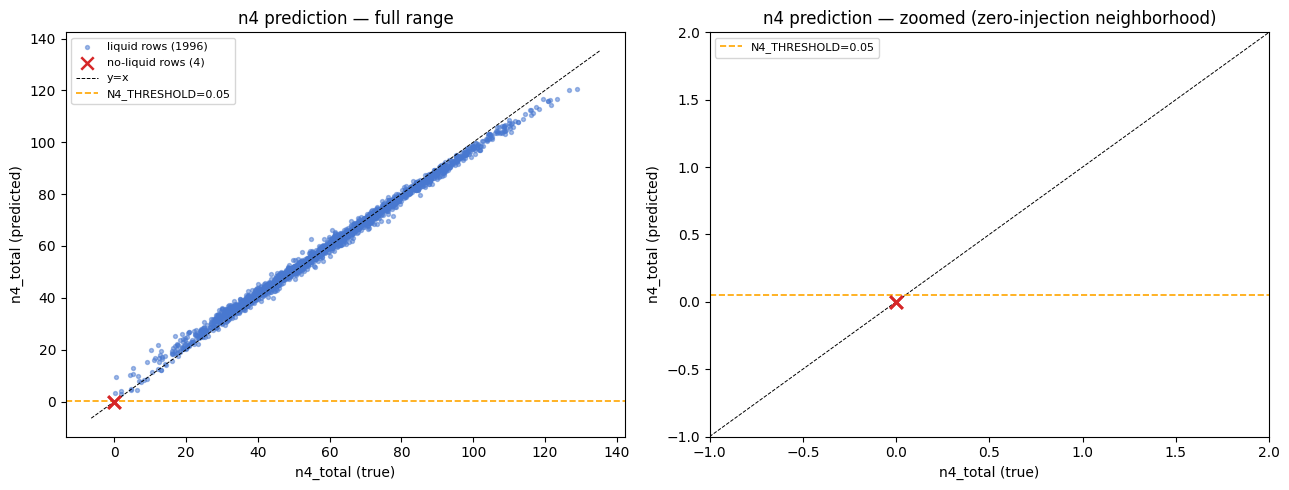

In [13]:
mhmlp_test_diagnostics = regime_diagnostics(
    data.y_test, test_pred_full, data.no_liquid_test, columns=OUTPUT_COLS
)
print("Regime diagnostics (all / liquid / no-liquid):")
print(mhmlp_test_diagnostics.round(5).to_string(index=False))

# --- n4-prediction diagnostic on every test row ---
n4_pred_raw = test_pred_full["n4_total"].values   # post-zero-injection (but the prediction itself is pre-injection)
# Note: zero-injection rewrites x_*_4 but NOT n4_total itself, so this is the raw predicted n4.
n4_true     = data.y_test["n4_total"].values
no_liquid_mask = data.no_liquid_test.values.astype(bool)
liquid_mask    = ~no_liquid_mask

print(f"\nn4 prediction summary:")
print(f"  Liquid rows    ({liquid_mask.sum():4d}): "
      f"pred mean={n4_pred_raw[liquid_mask].mean():.3f}, "
      f"min={n4_pred_raw[liquid_mask].min():.3f}, "
      f"max={n4_pred_raw[liquid_mask].max():.3f}")
if no_liquid_mask.any():
    print(f"  No-liquid rows ({no_liquid_mask.sum():4d}): "
          f"pred mean={n4_pred_raw[no_liquid_mask].mean():.4f}, "
          f"min={n4_pred_raw[no_liquid_mask].min():.4f}, "
          f"max={n4_pred_raw[no_liquid_mask].max():.4f}")

n_injected = int((n4_pred_raw <= N4_THRESHOLD).sum())
n_injected_no_liquid = int(((n4_pred_raw <= N4_THRESHOLD) & no_liquid_mask).sum())
n_injected_liquid    = int(((n4_pred_raw <= N4_THRESHOLD) & liquid_mask).sum())
print(f"\nZero-injection breakdown (N4_THRESHOLD = {N4_THRESHOLD}):")
print(f"  fired on {n_injected} test rows total "
      f"({n_injected_no_liquid} true no-liquid, {n_injected_liquid} false-positive)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full range
ax = axes[0]
ax.scatter(n4_true[liquid_mask], n4_pred_raw[liquid_mask],
           c="#4878d0", s=8, alpha=0.5, label=f"liquid rows ({liquid_mask.sum()})", rasterized=True)
if no_liquid_mask.any():
    ax.scatter(n4_true[no_liquid_mask], n4_pred_raw[no_liquid_mask],
               c="#d62728", s=80, marker="x", linewidths=1.8,
               label=f"no-liquid rows ({no_liquid_mask.sum()})", zorder=5)
ax_min, ax_max = min(n4_true.min(), n4_pred_raw.min()), max(n4_true.max(), n4_pred_raw.max())
pad = (ax_max - ax_min) * 0.05
ax.plot([ax_min - pad, ax_max + pad], [ax_min - pad, ax_max + pad],
        "k--", lw=0.7, label="y=x")
ax.axhline(N4_THRESHOLD, color="orange", lw=1.2, ls="--",
           label=f"N4_THRESHOLD={N4_THRESHOLD}")
ax.set_xlabel("n4_total (true)")
ax.set_ylabel("n4_total (predicted)")
ax.set_title("n4 prediction — full range")
ax.legend(fontsize=8)

# Zoomed near 0
ax = axes[1]
if no_liquid_mask.any():
    # Zoom in on the no-liquid neighborhood
    zoom_lo, zoom_hi = -1.0, max(2.0, 2 * N4_THRESHOLD + 0.5)
    ax.scatter(n4_true[liquid_mask], n4_pred_raw[liquid_mask],
               c="#4878d0", s=8, alpha=0.5, rasterized=True)
    ax.scatter(n4_true[no_liquid_mask], n4_pred_raw[no_liquid_mask],
               c="#d62728", s=80, marker="x", linewidths=1.8, zorder=5)
    ax.plot([zoom_lo, zoom_hi], [zoom_lo, zoom_hi], "k--", lw=0.7)
    ax.axhline(N4_THRESHOLD, color="orange", lw=1.2, ls="--",
               label=f"N4_THRESHOLD={N4_THRESHOLD}")
    ax.set_xlim(zoom_lo, zoom_hi); ax.set_ylim(zoom_lo, zoom_hi)
    ax.set_xlabel("n4_total (true)")
    ax.set_ylabel("n4_total (predicted)")
    ax.set_title("n4 prediction — zoomed (zero-injection neighborhood)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12. Comparison vs Task 2 baselines, Deep MLP, and Residual MLP

Elastic Net and XGBoost aggregates are taken from `EDA&ElasticNet.ipynb` and
`XGBoost.ipynb`. Deep MLP and Residual MLP metrics are loaded from their
checkpoints in `models/task3/`.

Note on comparability: the Multi-Head row uses the zero-injected
predictions (defined in section 3). The Deep MLP and Residual MLP rows are loaded
verbatim from their checkpoints and were not evaluated with
zero-injection. The aggregate comparison is therefore slightly in
favor of Multi-Head on the no-liquid rows (4 of 2000); the bulk
liquid-row comparison is still a fair comparison.

In [14]:
import torch as _torch

elastic_net_test = {"RMSE": 0.657, "MAE": 0.486, "R2": 0.938}
xgboost_test     = {"RMSE": 0.289, "MAE": 0.224, "R2": 0.987}

# Pull Deep MLP and Residual MLP test aggregates from their checkpoints.
_deep_ckpt  = _torch.load("models/task3/deep.pt",     map_location="cpu", weights_only=False)
_resid_ckpt = _torch.load("models/task3/residual.pt", map_location="cpu", weights_only=False)
dmlp_test_agg = {k: float(v) for k, v in _deep_ckpt["extra"]["test_agg"].items()}
rmlp_test_agg = {k: float(v) for k, v in _resid_ckpt["extra"]["test_agg"].items()}

mhmlp_test_agg = {
    "RMSE": mhmlp_m["RMSE"].mean(),
    "MAE":  mhmlp_m["MAE"].mean(),
    "R2":   mhmlp_m["R2"].mean(skipna=True),
}

comparison = pd.DataFrame({
    "Elastic Net (test)":     elastic_net_test,
    "XGBoost (test)":         xgboost_test,
    "Deep MLP (test)":        dmlp_test_agg,
    "Residual MLP (test)":    rmlp_test_agg,
    "Multi-Head MLP (test)":  mhmlp_test_agg,
}).T
comparison["RMSE_vs_XGB"] = comparison["RMSE"] - xgboost_test["RMSE"]
comparison["R2_vs_XGB"]   = comparison["R2"]   - xgboost_test["R2"]

print("Aggregate test comparison:")
comparison.round(5)

Aggregate test comparison:


,RMSE,MAE,R2,RMSE_vs_XGB,R2_vs_XGB
Elastic Net (test),0.65700,0.48600,0.93800,0.36800,-0.04900
XGBoost (test),0.28900,0.22400,0.98700,0.00000,0.00000
Deep MLP (test),1.81498,1.36422,0.98270,1.52598,-0.00430
Residual MLP (test),0.42661,0.29002,0.99213,0.13761,0.00513
Multi-Head MLP (test),1.31279,1.00979,0.98743,1.02379,0.00043


In [15]:
# Per-output R² for the outputs previously identified as weakest under
# Elastic Net / XGBoost / Deep MLP / Residual MLP.
weak_outputs = ["y_H2O_3", "Q2_MW", "MeOH_recovery", "x_H2_4", "x_CO_4", "x_MeOH_4"]
en_weak    = {"y_H2O_3": 0.752, "Q2_MW": 0.836, "MeOH_recovery": 0.858}
xgb_weak   = {"y_H2O_3": 0.994, "Q2_MW": 0.989, "MeOH_recovery": 0.998,
              "x_H2_4": 0.890, "x_CO_4": 0.963, "x_MeOH_4": 0.962}
dmlp_weak  = {"y_H2O_3": 0.987, "Q2_MW": 0.977, "MeOH_recovery": 0.991,
              "x_H2_4": 0.942, "x_CO_4": 0.977, "x_MeOH_4": 0.962}
rmlp_weak  = {"y_H2O_3": 0.9954, "Q2_MW": 0.9946, "MeOH_recovery": 0.9931,
              "x_H2_4": 0.9434, "x_CO_4": 0.9871, "x_MeOH_4": 0.9588}

mhmlp_weak = mhmlp_test_per_output.set_index("output")["R2"].loc[weak_outputs].to_dict()

weak_comparison = pd.DataFrame({
    "Elastic Net R²":      en_weak,
    "XGBoost R²":          xgb_weak,
    "Deep MLP R²":         dmlp_weak,
    "Residual MLP R²":     rmlp_weak,
    "Multi-Head MLP R²":   mhmlp_weak,
}).T

print("Per-output R² on previously-weak outputs:")
weak_comparison.round(4)

Per-output R² on previously-weak outputs:


,y_H2O_3,Q2_MW,MeOH_recovery,x_H2_4,x_CO_4,x_MeOH_4
Elastic Net R²,0.7520,0.8360,0.8580,NaN,NaN,NaN
XGBoost R²,0.9940,0.9890,0.9980,0.8900,0.9630,0.9620
Deep MLP R²,0.9870,0.9770,0.9910,0.9420,0.9770,0.9620
Residual MLP R²,0.9954,0.9946,0.9931,0.9434,0.9871,0.9588
Multi-Head MLP R²,0.9931,0.9838,0.9898,0.8935,0.9916,0.9901


## 13. Parity plots

Full 19-output parity grid using the zero-injected predictions. Train
predictions on validation-fold rows only (the model hasn't seen those during
training); test predictions on the entire held-out test set.

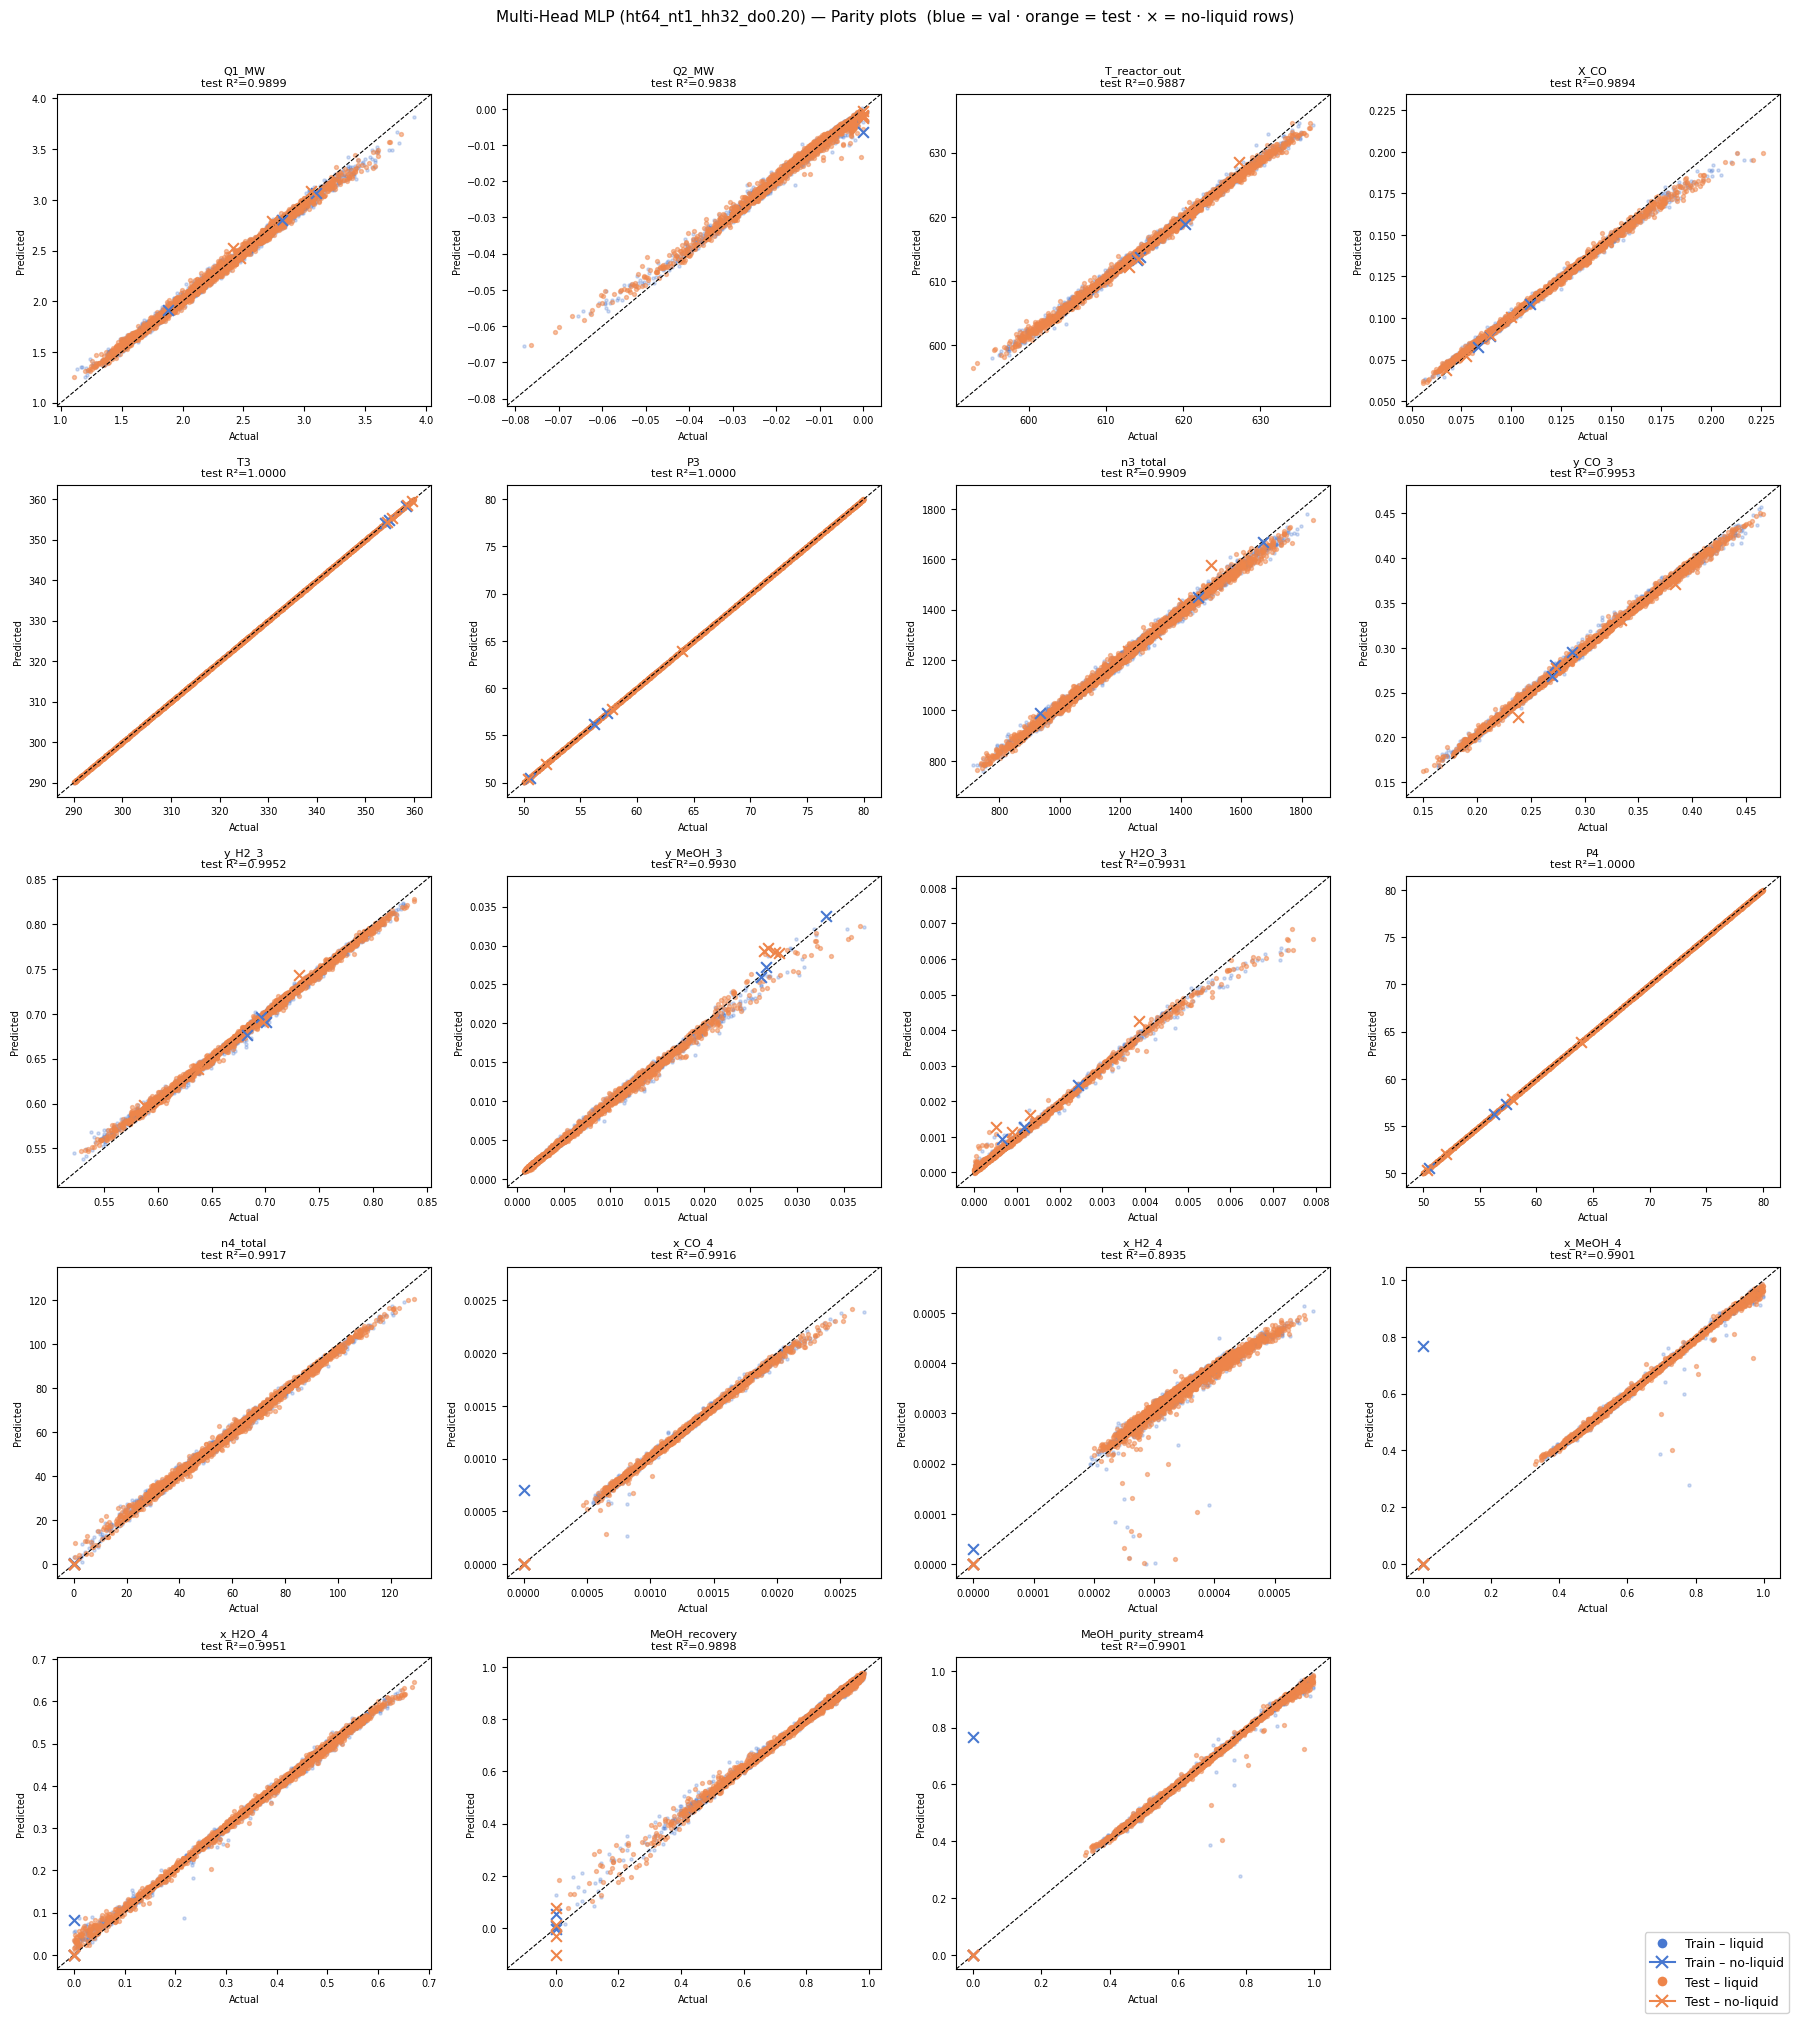

In [16]:
val_pred_modeled = predict_raw(model, scaled.X_val_s, scaled.Y_transformer, device=device)
val_pred_full    = assemble_with_zero_injection(
    val_pred_modeled, data.X_train.iloc[scaled.val_idx], n4_threshold=N4_THRESHOLD
)
y_val_true       = data.y_train.iloc[scaled.val_idx]
no_liquid_val_series = data.no_liquid_train.iloc[scaled.val_idx]

fig = parity_grid(
    y_train_true=y_val_true,
    y_train_pred=val_pred_full,
    y_test_true=data.y_test,
    y_test_pred=test_pred_full,
    no_liquid_train=no_liquid_val_series,
    no_liquid_test=data.no_liquid_test,
    columns=OUTPUT_COLS,
    title=f"Multi-Head MLP ({winner_name}) — Parity plots  (blue = val · orange = test · × = no-liquid rows)",
)
plt.show()

## 14. Save checkpoint

Save model weights, scalers, history, winning hyperparameters, and
`N4_THRESHOLD` (so Task 4 reload can reproduce the zero-injection) to
`models/task3/multihead.pt`. Task 4 (constrained optimization) reloads this
file with `torch.load(...)` and uses it as the differentiable surrogate.

In [17]:
save_checkpoint(
    "models/task3/multihead.pt",
    model,
    scaled,
    history,
    extra={
        # --- Architecture identity ---
        "architecture":      "MultiHeadMLP_plain_3head_v2",
        "head_grouping":     {
            "scalar": list(MultiHeadMLP.SCALAR_IDX),
            "vapor":  list(MultiHeadMLP.VAPOR_IDX),
            "liquid": list(MultiHeadMLP.LIQUID_IDX),
        },

        # --- Constructor args needed to re-instantiate MultiHeadMLP(...) ---
        "in_dim":            len(INPUT_COLS),
        "h_trunk":            winner_cfg["h_trunk"],
        "n_trunk_layers":    winner_cfg["n_trunk_layers"],
        "h_head":            winner_cfg["h_head"],
        "dropout":           winner_cfg["dropout"],
        "activation":        "GELU",
        "norm":              "LayerNorm",

        # --- Inference-time zero-injection threshold (local helper) ---
        "n4_threshold":      N4_THRESHOLD,
        "zero_injection_target_cols": ["n4_total",
                                       "x_CO_4", "x_H2_4", "x_MeOH_4", "x_H2O_4",
                                       "MeOH_purity_stream4"],

        # --- Training metadata ---
        "winner":            winner_name,
        "lr":                LR,
        "weight_decay":      WD,
        "es_patience":       ES_PATIENCE,
        "lr_patience":       5,
        "lr_min":            1e-8,
        "batch_size":        BATCH_SIZE,
        "random_state":      RANDOM_STATE,

        # --- Results & sweep audit trail ---
        "test_agg":          mhmlp_test_agg,
        "sweep_results":     sweep_df.to_dict(orient="records"),
    },
)
print("Saved models/task3/multihead.pt")
print(f"  architecture : MultiHeadMLP_plain_3head_v2")
print(f"  constructor  : h_trunk={winner_cfg['h_trunk']}, n_trunk_layers={winner_cfg['n_trunk_layers']}, "
      f"h_head={winner_cfg['h_head']}, dropout={winner_cfg['dropout']}")
print(f"  inference    : N4_THRESHOLD={N4_THRESHOLD} (local zero-injection on x_*_4)")

Saved models/task3/multihead.pt
  architecture : MultiHeadMLP_plain_3head_v2
  constructor  : h_trunk=64, n_trunk_layers=1, h_head=32, dropout=0.2
  inference    : N4_THRESHOLD=0.05 (local zero-injection on x_*_4)


## 15. Summary

The 8-config sweep (dropout, depth, head-width) selects
`ht64_nt1_hh32_do0.20`: `h_trunk=64, n_trunk_layers=1, h_head=32,
dropout=0.20`, just 7,503 params, as the best plain 3-head Multi-Head MLP,
with test R² = 0.98743 (it edges past XGBoost's 0.987). The checkpoint at
`models/task3/multihead.pt` is loadable in a fresh session and is referenced in
the cross-architecture comparison in `NN_PINN.ipynb` and `NN_Ensemble.ipynb`.

Dropout finding (this sweep): adding dropout as a swept axis confirms that
the lighter 0.20 beats 0.30 here. Averaged over the other axes, 0.20 gives
val loss 0.0514 vs 0.30's 0.0588, and the selected 0.20 model improves the
previous 0.30 winner from test R² 0.98405 to 0.98743 while using half the
parameters (7.5k vs 14.2k). The effect interacts strongly with head width: the
`nt1/hh32` config is the worst at dropout 0.30 but the best at 0.20, that is, the
narrow 32-unit heads are over-regularised by 0.30 and need the lighter 0.20.
This matches the Residual MLP's own 0.20 choice.

Design summary: shared trunk, then 3 heads (scalar / vapor / liquid). Plain
MSE in standardized space, no gating, no cascade, no auxiliary losses. The
winner is chosen on validation loss only (the test set is touched only once,
on the winner, in section 9). The no-liquid regime is handled at inference time by the
local `assemble_with_zero_injection` helper (defined in section 3): wherever the model
predicts `n4_total <= N4_THRESHOLD`, the four `x_*_4` mole fractions are forced
to 0 (and `MeOH_purity_stream4` follows). `nn_utils.assemble_full_prediction`
is unchanged.

Retrospective on the cascaded-gate attempt (reverted): the first version of
this notebook tried a cascaded gate. `head_n4` predicted `n4_total` and its
detached output drove a learnable sigmoid gate `sigmoid(k*(n4_pred - tau))` that
softly mixed `head_liquid`'s output with a learnable `zero_proxy` baseline
initialized to the standardized no-liquid target. Aggregate test R²
dropped to 0.96067 (vs 0.99213 for Residual MLP iter-2) and every
per-output metric got worse. The main cause: the gate value on no-liquid rows mean
ended at 0.9499 (it should be near 0), because only 10 no-liquid training rows
cannot teach the threshold parameter `tau` against 6390 liquid rows. The
`zero_proxy` value of -24 for `x_H2_4` (log of the 1e-10 floor, standardized)
also added a constant bias to liquid-row predictions through
the `(1 - gate)` term. Lesson: architecture cannot make up for sparse
class signal; the no-liquid regime is a data problem and is better
handled at inference (zero-injection), not in the forward pass.